##PUNTO 1

In [7]:
import numpy as np

In [8]:
def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    """
    Función característica del log-precio bajo Q
    (VERSIÓN DEFINITIVA: Estable ante overflow y división por cero).
    """
    z = np.asarray(z, dtype=np.complex128)

    mu_hat0 = r0 - 0.5 * sigma0**2
    mu_hat1 = r1 - 0.5 * sigma1**2

    mu_plus    = (mu_hat0 + mu_hat1) / 2
    mu_minus   = (mu_hat0 - mu_hat1) / 2
    sigma_plus  = (sigma0**2 + sigma1**2) / 4
    sigma_minus = (sigma0**2 - sigma1**2) / 4
    lam_plus  = (lam0 + lam1) / 2
    lam_minus = (lam0 - lam1) / 2

    rho_plus  = 1j * z * mu_plus  - sigma_plus  * z**2 - lam_plus
    rho_minus = 1j * z * mu_minus - sigma_minus * z**2 - lam_minus

    D = rho_minus**2 + lam0 * lam1
    sqrt_D = np.sqrt(D)

    # --- PARCHE 1: Evitar división por cero de forma segura ---
    safe_sqrt_D = np.where(sqrt_D == 0, 1.0, sqrt_D)

    if regime == 0:
        c = (rho_minus + lam0) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 + (rho_minus + lam0) * T)
    else:
        c = -(rho_minus - lam1) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 - (rho_minus - lam1) * T)

    # --- PARCHE 2: Formulación estable para evitar (0.0 * inf = nan) ---
    term1 = 0.5 * np.exp(T * (rho_plus + sqrt_D)) * (1.0 + c)
    term2 = 0.5 * np.exp(T * (rho_plus - sqrt_D)) * (1.0 - c)
    stable_phi = term1 + term2

    # Retornamos el límite si D=0, o la función estable en cualquier otro caso
    return np.where(sqrt_D == 0, limit_val, stable_phi)

# Punto 2


In [9]:
# ---------- (a) Sin cambio de regimen: comparacion con Browniano con drift ----------
z_test = np.linspace(-5, 5, 200) + 0j
T_test = 1.0
r, sigma = 0.05, 0.2

phi_mm = char_func_markov(z_test, T_test, r, r, sigma, sigma,
                          0.0, 0.0, regime=0)
mu_hat = r - 0.5 * sigma**2
phi_bs = np.exp(1j * z_test * mu_hat * T_test
                - 0.5 * sigma**2 * z_test**2 * T_test)

print("Error max (sin regimen):", np.max(np.abs(phi_mm - phi_bs)))

# ---------- (b) Condicion inicial phi(z, 0) = 1 ----------
for regime in (0, 1):
    phi_0 = char_func_markov(z_test, 0.0, 0.05, 0.03,
                             0.2, 0.4, 2.0, 3.0, regime=regime)
    print(f"Error max (t=0, regimen {regime}):", np.max(np.abs(phi_0 - 1.0)))

# ---------- (c) Primer momento: -i * phi'(0, T) vs. E[X_T] analitico ----------
T, r0, r1 = 1.0, 0.05, 0.03
sigma0, sigma1 = 0.2, 0.4
lam0, lam1 = 2.0, 3.0

mu0 = r0 - 0.5 * sigma0**2
mu1 = r1 - 0.5 * sigma1**2
pi0 = lam1 / (lam0 + lam1)
pi1 = 1 - pi0
mu_stat = pi0 * mu0 + pi1 * mu1
transient = (1 - np.exp(-(lam0 + lam1) * T)) / (lam0 + lam1)

h = 1e-5
for regime in (0, 1):
    mu_i = mu0 if regime == 0 else mu1
    mu_j = mu1 if regime == 0 else mu0
    pi_j = pi1 if regime == 0 else pi0
    E_analytic = mu_stat * T + pi_j * transient * (mu_i - mu_j)

    phi_p = char_func_markov(np.array([+h]), T, r0, r1, sigma0, sigma1, lam0, lam1, regime)[0]
    phi_m = char_func_markov(np.array([-h]), T, r0, r1, sigma0, sigma1, lam0, lam1, regime)[0]
    E_fd = float(np.real(-1j * (phi_p - phi_m) / (2 * h)))

    print(f"regimen {regime}: E[X_T] analitico = {E_analytic: .8f}, "
          f"-i*phi'(0,T) = {E_fd: .8f}, error = {abs(E_fd - E_analytic):.2e}")

Error max (sin regimen): 0.0
Error max (t=0, regimen 0): 1.1102230246251565e-16
Error max (t=0, regimen 1): 0.0
regimen 0: E[X_T] analitico =  0.00435688, -i*phi'(0,T) =  0.00435688, error = 1.38e-14
regimen 1: E[X_T] analitico = -0.01153532, -i*phi'(0,T) = -0.01153532, error = 9.38e-14


# Punto 3


In [10]:
import numpy as np

def carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1,
                   regime=0, N=4096, alpha=1.5, eta=0.25):
    """
    Valoración de calls europeas por Carr-Madan FFT
    en el modelo Markov-modulado con tasa constante r.

    Parámetros
    ----------
    S0 : float
        Precio spot inicial.
    T : float
        Vencimiento.
    r : float
        Tasa libre de riesgo constante.
    sigma0, sigma1 : float
        Volatilidades por régimen.
    lam0, lam1 : float
        Intensidades de cambio de régimen.
    regime : int
        Régimen inicial, 0 o 1.
    N : int
        Número de puntos de la FFT.
    alpha : float
        Parámetro de amortiguamiento.
    eta : float
        Paso en frecuencia.

    Retorna
    -------
    strikes : np.ndarray
        Vector de strikes.
    prices : np.ndarray
        Vector de precios call.
    """
    if N <= 0 or (N & (N - 1)) != 0:
        raise ValueError("N debe ser potencia de 2 para una FFT eficiente.")
    if alpha <= 0:
        raise ValueError("alpha debe ser positivo.")
    if eta <= 0:
        raise ValueError("eta debe ser positivo.")
    if regime not in (0, 1):
        raise ValueError("regime debe ser 0 o 1.")

    # Relación eta * dk = 2*pi/N
    dk = 2.0 * np.pi / (N * eta)
    b = 0.5 * N * dk

    # Grilla de frecuencias
    j = np.arange(N)
    nu = j * eta

    # Pesos de Simpson 1/3 con corrección Kronecker (Carr-Madan 1999):
    # 1/3, 4/3, 2/3, 4/3, 2/3, ...
    w = np.ones(N)
    w[0] = 1.0 / 3.0
    w[1::2] = 4.0 / 3.0
    w[2::2] = 2.0 / 3.0

    # Shift complejo de Carr-Madan
    z = nu - 1j * (alpha + 1.0)

    # Función característica del log-retorno x_T = ln(S_T / S_0)
    phi = char_func_markov(
        z, T, r, r, sigma0, sigma1, lam0, lam1, regime=regime
    )

    # Transformada del precio amortiguado
    denom = (alpha + 1j * nu) * (alpha + 1.0 + 1j * nu)
    psi = np.exp(-r * T) * phi / denom

    # Entrada a la FFT
    x = np.exp(1j * b * nu) * psi * eta * w

    # FFT
    y = np.fft.fft(x)

    # Como char_func_markov es la función característica del log-RETORNO
    # x_T = ln(S_T/S_0), la inversión FFT produce naturalmente precios en
    # la grilla de log-moneyness u = ln(K/S_0). Entonces:
    #   C(K) = S_0 * e^{-alpha*u} / pi * Re(y).
    # El factor S_0 proviene de factorizar el payoff
    # (S_T - K)_+ = S_0 * (exp(x_T) - K/S_0)_+.
    u = -b + j * dk
    strikes = S0 * np.exp(u)
    prices = S0 * np.exp(-alpha * u) * np.real(y) / np.pi

    # Limpieza numérica simple
    prices = np.maximum(prices, 0.0)

    # Filtrar región razonable alrededor de S0
    mask = (strikes > 0.3 * S0) & (strikes < 3.0 * S0)

    return strikes[mask], prices[mask]

In [11]:
#Pequeña prueba de verificacion
S0, T, r = 100.0, 0.5 , 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

K_fft, C_fft = carr_madan_fft(
    S0, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, N=4096, alpha=1.5, eta=0.25
)

print("Número de strikes devueltos:", len(K_fft))
print("Primeros 5 strikes:", K_fft[:5])
print("Primeros 5 precios:", C_fft[:5])

Número de strikes devueltos: 376
Primeros 5 strikes: [30.03998262 30.2248723  30.41089993 30.59807253 30.78639713]
Primeros 5 precios: [70.40725459 70.2251176  70.0418596  69.8574737  69.67195294]


# Punto 4

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import norm


def bs_call(S0, K, T, r, sigma):
    """Fórmula cerrada de Black-Scholes para una call europea."""
    K = np.asarray(K, dtype=float)
    sqrtT = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / sqrtT
    d2 = d1 - sqrtT
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# Parametros del enunciado (variables propias del punto 4)
S0_bs, T_bs, r_bs, sigma_bs = 100.0, 1.0, 0.05, 0.2

K_fft_bs, C_fft_bs = carr_madan_fft(
    S0_bs, T_bs, r_bs, sigma_bs, sigma_bs, 0.0, 0.0,
    regime=0, N=4096, alpha=1.5, eta=0.25,
)
C_bs_ref = bs_call(S0_bs, K_fft_bs, T_bs, r_bs, sigma_bs)

err_abs_bs = np.abs(C_fft_bs - C_bs_ref)
mask_atm_bs = (K_fft_bs > 0.7 * S0_bs) & (K_fft_bs < 1.3 * S0_bs)

err_max_global = err_abs_bs.max()
err_max_atm = err_abs_bs[mask_atm_bs].max()
k_worst_global = K_fft_bs[err_abs_bs.argmax()]
k_worst_atm = K_fft_bs[mask_atm_bs][err_abs_bs[mask_atm_bs].argmax()]

print(f"Strikes evaluados:              {len(K_fft_bs)}")
print(f"Rango de strikes:               [{K_fft_bs.min():.2f}, {K_fft_bs.max():.2f}]")
print(f"Error absoluto maximo (total):  {err_max_global:.4e}  en K = {k_worst_global:.4f}")
print(f"Error absoluto maximo (ATM):    {err_max_atm:.4e}  en K = {k_worst_atm:.4f}")

i_atm_bs = np.argmin(np.abs(K_fft_bs - S0_bs))
print(f"\nEn K = {K_fft_bs[i_atm_bs]:.4f} (ATM):")
print(f"  Call FFT = {C_fft_bs[i_atm_bs]:.8f}")
print(f"  Call BS  = {C_bs_ref[i_atm_bs]:.8f}")
print(f"  Error    = {abs(C_fft_bs[i_atm_bs] - C_bs_ref[i_atm_bs]):.4e}")

Strikes evaluados:              376
Rango de strikes:               [30.04, 299.92]
Error absoluto maximo (total):  2.1708e-07  en K = 30.2249
Error absoluto maximo (ATM):    2.1708e-07  en K = 70.9204

En K = 100.0000 (ATM):
  Call FFT = 10.45058336
  Call BS  = 10.45058357
  Error    = 2.1708e-07


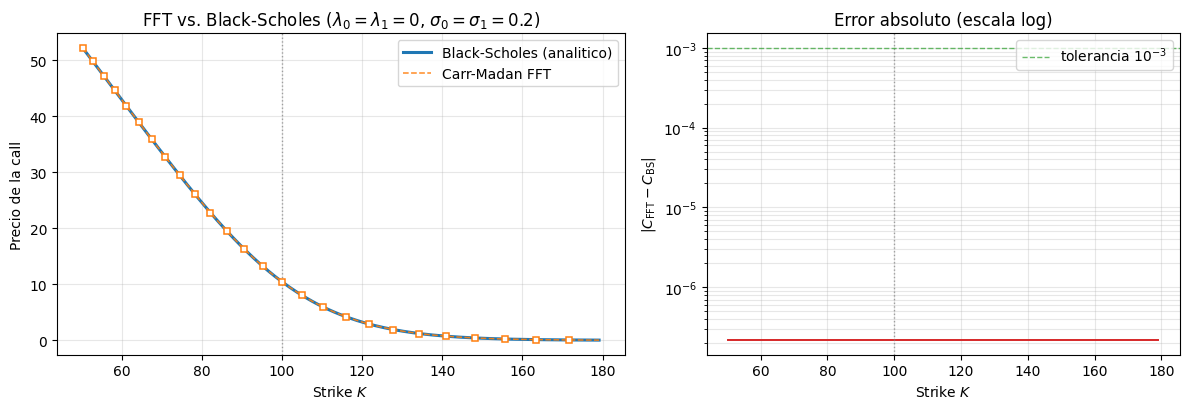

In [13]:
fig, (ax_price, ax_err) = plt.subplots(
    1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1.0]}
)

# --- Panel izquierdo: precios FFT vs BS en region ATM ampliada ---
plot_mask_bs = (K_fft_bs > 0.5 * S0_bs) & (K_fft_bs < 1.8 * S0_bs)
ax_price.plot(
    K_fft_bs[plot_mask_bs], C_bs_ref[plot_mask_bs],
    color="tab:blue", lw=2.2, label="Black-Scholes (analitico)",
)
ax_price.plot(
    K_fft_bs[plot_mask_bs], C_fft_bs[plot_mask_bs],
    color="tab:orange", lw=1.1, ls="--", alpha=0.9, label="Carr-Madan FFT",
)
ax_price.plot(
    K_fft_bs[plot_mask_bs][::8], C_fft_bs[plot_mask_bs][::8],
    linestyle="none", marker="s", markersize=4.2,
    markerfacecolor="white", markeredgecolor="tab:orange",
    markeredgewidth=1.1, zorder=3, label="_nolegend_",
)
ax_price.axvline(S0_bs, color="gray", ls=":", lw=1, alpha=0.7)
ax_price.set_xlabel("Strike $K$")
ax_price.set_ylabel("Precio de la call")
ax_price.set_title(r"FFT vs. Black-Scholes ($\lambda_0=\lambda_1=0$, $\sigma_0=\sigma_1=0.2$)")
ax_price.legend(loc="upper right")
ax_price.grid(True, alpha=0.3)

# --- Panel derecho: error absoluto en escala log ---
ax_err.semilogy(
    K_fft_bs[plot_mask_bs], np.maximum(err_abs_bs[plot_mask_bs], 1e-16),
    color="tab:red", lw=1.4,
)
ax_err.axvline(S0_bs, color="gray", ls=":", lw=1, alpha=0.7)
ax_err.axhline(1e-3, color="tab:green", ls="--", lw=1, alpha=0.7,
               label=r"tolerancia $10^{-3}$")
ax_err.set_xlabel("Strike $K$")
ax_err.set_ylabel(r"$|C_{\mathrm{FFT}} - C_{\mathrm{BS}}|$")
ax_err.set_title("Error absoluto (escala log)")
ax_err.legend(loc="upper right")
ax_err.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Punto 5

In [14]:
def cos_method(SO, K, T, r, sigma0, sigmal, lamo, lam1, regime=0, N=256, L=10, option_type='call'):
    """
    Valoracion de opciones europeas por el metodo COS
    en el modelo Markov-modulado con tasa constante r.
    """
    K = np.atleast_1d(np.float64(K))
    x = np.log(SO / K)

    # Cumulantes aproximados (usando promedio ponderado)
    # Probabilidad estacionaria: pi_0 = lam1 / (lamo + lam1)
    pi0 = lam1 / (lamo + lam1) if (lamo + lam1) > 0 else 0.5
    mu_avg = (pi0 * (r - 0.5 * sigma0**2) + (1 - pi0) * (r - 0.5 * sigmal**2))
    var_avg = pi0 * sigma0**2 + (1 - pi0) * sigmal**2

    c1 = mu_avg * T
    c2 = var_avg * T
    c4 = 0.0 # cuarto cumulante (aprox.)

    a = c1 - L * np.sqrt(c2 + np.sqrt(max(c4, 0)))
    b = c1 + L * np.sqrt(c2 + np.sqrt(max(c4, 0)))

    # Indices k=0, 1, N-1
    k_arr = np.arange(N)

    # Funcion caracteristica evaluada en k pi/(b-a)
    z_vals = k_arr * np.pi / (b - a)
    phi_vals = char_func_markov(z_vals, T, r, r, sigma0, sigmal, lamo, lam1, regime)

    # Coeficientes del payoff
    def chi_k(c, d, k_arr):
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        denom = 1 + (k_arr * np.pi / (b - a))**2
        num = (np.cos(arg_d) * np.exp(d) - np.cos(arg_c) * np.exp(c)
               + k_arr * np.pi / (b - a) * (np.sin(arg_d) * np.exp(d) - np.sin(arg_c) * np.exp(c)))
        return num / denom

    def psi_k(c, d, k_arr):
        result = np.zeros_like(k_arr, dtype=float)
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        nonzero = k_arr != 0
        result[nonzero] = ((np.sin(arg_d[nonzero]) - np.sin(arg_c[nonzero]))
                           * (b - a) / (k_arr[nonzero] * np.pi))
        result[~nonzero] = d - c
        return result

    if option_type == 'call':
        Vk = 2 / (b - a) * (chi_k(0, b, k_arr) - psi_k(0, b, k_arr))
    else:
        Vk = 2 / (b - a) * (-chi_k(a, 0, k_arr) + psi_k(a, 0, k_arr))

    # Precio para cada strike
    prices = np.zeros(len(K))
    for j, x_val in enumerate(x):
        # NOTA NECESARIA: Se añade "1j * z_vals * x_val" a la exponencial original
        # para que la variable del ciclo `x_val` haga efecto en cada iteración.
        exp_term = np.exp(1j * z_vals * x_val - 1j * k_arr * np.pi * a / (b - a))
        cos_coeffs = np.real(phi_vals * exp_term)
        cos_coeffs[0] *= 0.5 # factor 1/2 para k=0
        prices[j] = K[j] * np.exp(-r * T) * np.sum(cos_coeffs * Vk)

    return prices

In [15]:
import time
from scipy.interpolate import interp1d
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
regime = 0
K_test = np.array([90.0, 100.0, 110.0]) # Evaluaremos ITM, ATM y OTM

print("Iniciando valoración...\n")

# --- Método FFT ---
t0_fft = time.time()
K_fft, C_fft = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=regime)
t_fft_end = time.time()

# Interpolamos la malla del FFT para que coincida con los strikes K_test
interpolador_fft = interp1d(K_fft, C_fft, kind='cubic')
precios_fft_interp = interpolador_fft(K_test)

# --- Método COS ---
t0_cos = time.time()
precios_cos = cos_method(S0, K_test, T, r, sigma0, sigma1, lam0, lam1, regime=regime, option_type='call')
t_cos_end = time.time()

# --- Consola de Resultados ---
print(f"--- Tiempos de Ejecución ---")
print(f"Método FFT : {(t_fft_end - t0_fft)*1000:.2f} ms (Generó {len(K_fft)} strikes simultáneamente)")
print(f"Método COS : {(t_cos_end - t0_cos)*1000:.2f} ms (Generó {len(K_test)} strikes especificos)\n")

print(f"{'Strike (K)':<12} | {'Precio COS':<15} | {'Precio FFT':<15} | {'Diferencia Absoluta':<20}")
print("-" * 68)
for i in range(len(K_test)):
    diff = abs(precios_cos[i] - precios_fft_interp[i])
    print(f"{K_test[i]:<12.1f} | {precios_cos[i]:<15.6f} | {precios_fft_interp[i]:<15.6f} | {diff:.2e}")

Iniciando valoración...

--- Tiempos de Ejecución ---
Método FFT : 2.53 ms (Generó 376 strikes simultáneamente)
Método COS : 0.24 ms (Generó 3 strikes especificos)

Strike (K)   | Precio COS      | Precio FFT      | Diferencia Absoluta 
--------------------------------------------------------------------
90.0         | 13.198930       | 13.198930       | 2.13e-07
100.0        | 6.776006        | 6.776005        | 2.17e-07
110.0        | 3.051285        | 3.051285        | 2.09e-07


# Punto 6

In [16]:
import time
from scipy.interpolate import interp1d
from scipy.optimize import brentq

# --- Parametros base (Taller sec. 6.1) ---
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
K_atm = 100.0
K_smile = np.linspace(70.0, 130.0, 61)

# ========= (a) Precio ATM por FFT y COS, regimen 0 =========
# FFT: evalua la malla completa y se interpola al strike deseado
t0 = time.perf_counter()
K_fft_0, C_fft_0 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=0)
f_fft_0 = interp1d(K_fft_0, C_fft_0, kind="cubic")
price_fft_atm = float(f_fft_0(K_atm))
t_fft_atm = time.perf_counter() - t0

# COS: directo en K=100
t0 = time.perf_counter()
price_cos_atm = float(
    cos_method(S0, np.array([K_atm]), T, r, sigma0, sigma1, lam0, lam1,
               regime=0, option_type="call")[0]
)
t_cos_atm = time.perf_counter() - t0

print("(a) Precio de la call ATM (S0=K=100, T=0.5, regimen 0)")
print(f"    FFT (interpolado):  {price_fft_atm:.6f}   ({t_fft_atm*1000:.2f} ms)")
print(f"    COS (directo):      {price_cos_atm:.6f}   ({t_cos_atm*1000:.2f} ms)")
print(f"    Diferencia abs.:    {abs(price_fft_atm - price_cos_atm):.3e}")

# ========= (b) Tiempos para la sonrisa completa (61 strikes) =========
# FFT: la malla se reusa (una sola FFT) y se interpolan 61 strikes
t0 = time.perf_counter()
K_fft_0, C_fft_0 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=0)
f_fft_0 = interp1d(K_fft_0, C_fft_0, kind="cubic")
C_fft_smile_0 = f_fft_0(K_smile)
t_fft_smile = time.perf_counter() - t0

# COS: un strike por llamada (loop interno dentro de cos_method)
t0 = time.perf_counter()
C_cos_smile_0 = cos_method(
    S0, K_smile, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, option_type="call",
)
t_cos_smile = time.perf_counter() - t0

print(f"\n(b) Tiempos para construir la sonrisa completa ({len(K_smile)} strikes)")
print(f"    FFT (N=4096 + interp. cubica):  {t_fft_smile*1000:6.2f} ms")
print(f"    COS (N=256 por strike):         {t_cos_smile*1000:6.2f} ms")
print(f"    Max diff FFT vs COS en sonrisa: {np.max(np.abs(C_fft_smile_0 - C_cos_smile_0)):.3e}")

(a) Precio de la call ATM (S0=K=100, T=0.5, regimen 0)
    FFT (interpolado):  6.776005   (2.09 ms)
    COS (directo):      6.776006   (0.17 ms)
    Diferencia abs.:    2.170e-07

(b) Tiempos para construir la sonrisa completa (61 strikes)
    FFT (N=4096 + interp. cubica):    0.84 ms
    COS (N=256 por strike):           0.87 ms
    Max diff FFT vs COS en sonrisa: 2.603e-07


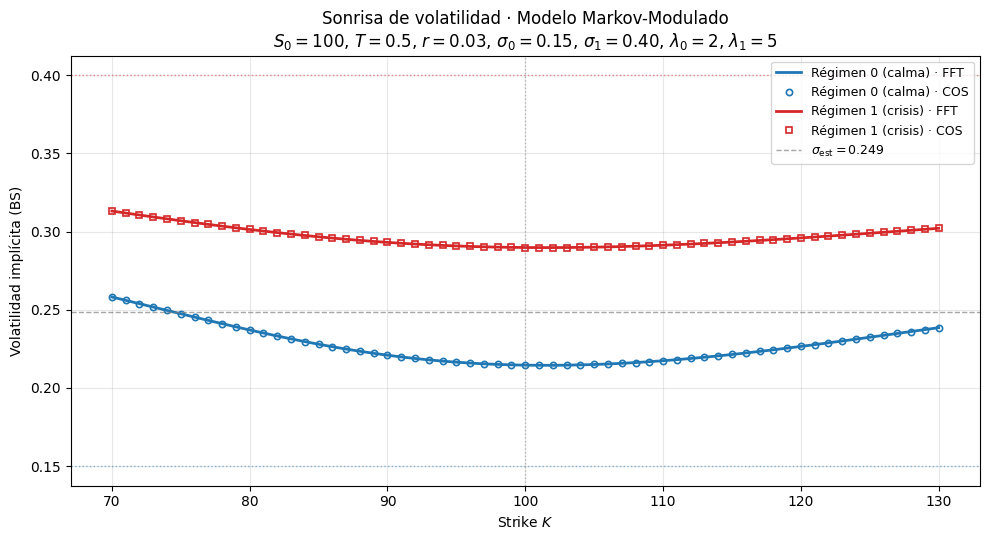

IV ATM régimen 0 (calma):  0.2146
IV ATM régimen 1 (crisis): 0.2898
IV estacionaria (ref.):    0.2486
Volatilidades nominales:   sigma0=0.15, sigma1=0.40


In [17]:
# ========= (c) y (d): Sonrisa de volatilidad implicita (regimenes 0 y 1) =========

def implied_vol(C_market, S0, K, T, r):
    """Inversion de Black-Scholes via brentq, con chequeo de cotas no-arbitraje."""
    intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
    if not np.isfinite(C_market) or C_market <= intrinsic - 1e-12 or C_market >= S0:
        return np.nan
    def f(sigma):
        return bs_call(S0, K, T, r, sigma) - C_market
    try:
        return brentq(f, 1e-4, 5.0, xtol=1e-10, maxiter=200)
    except ValueError:
        return np.nan


# Regimen 1: repetir el experimento con regime=1
K_fft_1, C_fft_1 = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1, regime=1)
f_fft_1 = interp1d(K_fft_1, C_fft_1, kind="cubic")
C_fft_smile_1 = f_fft_1(K_smile)
C_cos_smile_1 = cos_method(
    S0, K_smile, T, r, sigma0, sigma1, lam0, lam1,
    regime=1, option_type="call",
)

# Calcular IV para los cuatro conjuntos de precios
iv_fft_0 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_fft_smile_0, K_smile)])
iv_cos_0 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_cos_smile_0, K_smile)])
iv_fft_1 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_fft_smile_1, K_smile)])
iv_cos_1 = np.array([implied_vol(c, S0, k, T, r) for c, k in zip(C_cos_smile_1, K_smile)])

# Volatilidad estacionaria para referencia
pi0_stat = lam1 / (lam0 + lam1)
sigma_stat = np.sqrt(pi0_stat * sigma0**2 + (1 - pi0_stat) * sigma1**2)

fig, ax = plt.subplots(figsize=(10, 5.5))

# Regimen 0 (calma) -> azul
ax.plot(K_smile, iv_fft_0, "-", color="tab:blue", lw=2.0,
        label=r"Régimen 0 (calma) · FFT")
ax.plot(K_smile, iv_cos_0, "o", color="tab:blue", markersize=4.5,
        markerfacecolor="none", markeredgewidth=1.2,
        label=r"Régimen 0 (calma) · COS")

# Regimen 1 (crisis) -> rojo
ax.plot(K_smile, iv_fft_1, "-", color="tab:red", lw=2.0,
        label=r"Régimen 1 (crisis) · FFT")
ax.plot(K_smile, iv_cos_1, "s", color="tab:red", markersize=4.5,
        markerfacecolor="none", markeredgewidth=1.2,
        label=r"Régimen 1 (crisis) · COS")

ax.axhline(sigma0, color="tab:blue", ls=":", lw=1, alpha=0.5)
ax.axhline(sigma1, color="tab:red", ls=":", lw=1, alpha=0.5)
ax.axhline(sigma_stat, color="gray", ls="--", lw=1, alpha=0.7,
           label=fr"$\sigma_{{\mathrm{{est}}}}={sigma_stat:.3f}$")
ax.axvline(S0, color="gray", ls=":", lw=1, alpha=0.5)

ax.set_xlabel("Strike $K$")
ax.set_ylabel("Volatilidad implícita (BS)")
ax.set_title(
    "Sonrisa de volatilidad · Modelo Markov-Modulado\n"
    r"$S_0=100$, $T=0.5$, $r=0.03$, $\sigma_0=0.15$, $\sigma_1=0.40$, "
    r"$\lambda_0=2$, $\lambda_1=5$"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

iv_atm_0 = iv_cos_0[np.argmin(np.abs(K_smile - S0))]
iv_atm_1 = iv_cos_1[np.argmin(np.abs(K_smile - S0))]
print(f"IV ATM régimen 0 (calma):  {iv_atm_0:.4f}")
print(f"IV ATM régimen 1 (crisis): {iv_atm_1:.4f}")
print(f"IV estacionaria (ref.):    {sigma_stat:.4f}")
print(f"Volatilidades nominales:   sigma0={sigma0:.2f}, sigma1={sigma1:.2f}")

#Punto 7


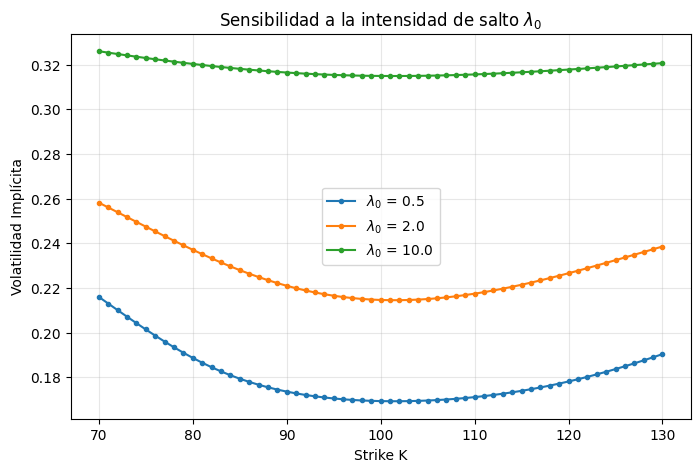

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros base
S0, T, r = 100, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam1 = 5.0
K_cos = np.linspace(70, 130, 61)

# Valores a iterar para el punto (a)
lam0_values = [0.5, 2.0, 10.0]

plt.figure(figsize=(8, 5))

for l0 in lam0_values:
    # 1. Calcular precios con COS
    C_cos = cos_method(S0, K_cos, T, r, sigma0, sigma1, l0, lam1, regime=0)

    # 2. Calcular volatilidad implícita
    iv_cos = [implied_vol(c, S0, k, T, r) for c, k in zip(C_cos, K_cos)]

    # 3. Graficar
    plt.plot(K_cos, iv_cos, marker='o', markersize=3, label=rf'$\lambda_0$ = {l0}')

plt.xlabel('Strike K')
plt.ylabel('Volatilidad Implícita')
plt.title(r'Sensibilidad a la intensidad de salto $\lambda_0$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Punto 8

--- Comparación de Greeks (Régimen 0) ---
Delta analítica: 0.564642 | FD: 0.573147
Gamma analítica: 0.027967 | FD: 0.028387



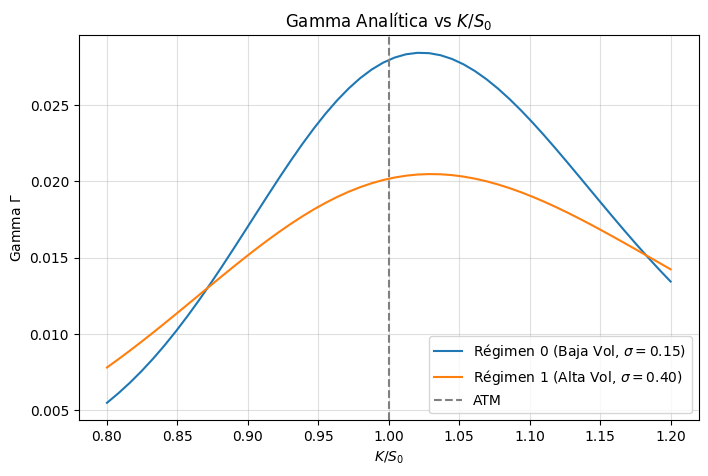

--- Convergencia de Gamma por Diferencias Finitas ---
Gamma Analítica Exacta: 0.027967
Paso h   | Gamma FD     | Error Absoluto 
----------------------------------------
2.0      | 0.028337     | 3.70e-04
1.0      | 0.028377     | 4.09e-04
0.5      | 0.028387     | 4.19e-04
0.1      | 0.028390     | 4.23e-04
0.05     | 0.028390     | 4.23e-04
0.01     | 0.028390     | 4.23e-04


In [19]:
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# (a) FÓRMULAS ANALÍTICAS VÍA FOURIER
# ==========================================

def delta_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    """Delta analítica vía inversión de Fourier [cite: 624-626]."""
    z_minus_i = np.array([-1j])
    phi_minus_i = char_func_markov(z_minus_i, T, r, r, sigma0, sigma1, lam0, lam1, regime)[0]

    def integrand(nu):
        z = np.array([nu - 1j])
        phi_val = char_func_markov(z, T, r, r, sigma0, sigma1, lam0, lam1, regime)[0]
        # np.real extrae la parte real como pide la fórmula de Gil-Pelaez [cite: 638-639]
        return np.real(np.exp(-1j * nu * np.log(K / S0)) * phi_val / (1j * nu * phi_minus_i))

    integral, _ = quad(integrand, 1e-8, 200, limit=500)
    Pi1 = 0.5 + integral / np.pi
    return np.exp(-r * T) * Pi1

def gamma_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    """Gamma analítica vía inversión de Fourier [cite: 641-643]."""
    z_minus_i = np.array([-1j])
    phi_minus_i = char_func_markov(z_minus_i, T, r, r, sigma0, sigma1, lam0, lam1, regime)[0]

    def integrand(nu):
        z = np.array([nu - 1j])
        phi_val = char_func_markov(z, T, r, r, sigma0, sigma1, lam0, lam1, regime)[0]
        return np.real(np.exp(-1j * nu * np.log(K / S0)) * phi_val / phi_minus_i)

    integral, _ = quad(integrand, 1e-8, 200, limit=500)
    return np.exp(-r * T) / (S0 * np.pi) * integral

# ==========================================
# (b) COMPARACIÓN CON DIFERENCIAS FINITAS
# ==========================================

# Parámetros Base
S0, K, T, r = 100.0, 100.0, 0.5, 0.03
sigma0, sigma1, lam0, lam1 = 0.15, 0.40, 2.0, 5.0
h = 0.5  # Paso para diferencias finitas [cite: 752]

# 1. Valores Analíticos
delta_a = delta_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)
gamma_a = gamma_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)

# 2. Valores por Diferencias Finitas usando Método COS [cite: 654-656]
C_up = cos_method(S0 + h, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]
C_md = cos_method(S0,     K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]
C_dn = cos_method(S0 - h, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]

delta_fd = (C_up - C_dn) / (2 * h)
gamma_fd = (C_up - 2 * C_md + C_dn) / (h**2)

print("--- Comparación de Greeks (Régimen 0) ---")
print(f"Delta analítica: {delta_a:.6f} | FD: {delta_fd:.6f}")
print(f"Gamma analítica: {gamma_a:.6f} | FD: {gamma_fd:.6f}\n")

# ==========================================
# (c) GRÁFICO DE LA GAMMA SEGÚN EL RÉGIMEN
# ==========================================

moneyness = np.linspace(0.8, 1.2, 50) # K/S0 [cite: 657]
K_vals = S0 * moneyness

gamma_regime_0 = [gamma_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=0) for k in K_vals]
gamma_regime_1 = [gamma_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=1) for k in K_vals]

plt.figure(figsize=(8, 5))
plt.plot(moneyness, gamma_regime_0, label=r'Régimen 0 (Baja Vol, $\sigma=0.15$)')
plt.plot(moneyness, gamma_regime_1, label=r'Régimen 1 (Alta Vol, $\sigma=0.40$)')
plt.title(r'Gamma Analítica vs $K/S_0$')
plt.xlabel(r'$K/S_0$')
plt.ylabel(r'Gamma $\Gamma$')
plt.axvline(1.0, color='grey', linestyle='--', label='ATM')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

# ==========================================
# (d) SENSIBILIDAD AL PASO h EN DIFERENCIAS FINITAS
# ==========================================

h_vals = [2.0, 1.0, 0.5, 0.1, 0.05, 0.01]
print("--- Convergencia de Gamma por Diferencias Finitas ---")
print(f"Gamma Analítica Exacta: {gamma_a:.6f}")
print(f"{'Paso h':<8} | {'Gamma FD':<12} | {'Error Absoluto':<15}")
print("-" * 40)

for h_step in h_vals:
    cup = cos_method(S0 + h_step, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]
    cmd = cos_method(S0,          K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]
    cdn = cos_method(S0 - h_step, K, T, r, sigma0, sigma1, lam0, lam1, regime=0)[0]

    g_fd = (cup - 2 * cmd + cdn) / (h_step**2)
    err = abs(gamma_a - g_fd)
    print(f"{h_step:<8} | {g_fd:.6f}     | {err:.2e}")

# Punto 9


Precio de referencia (N=2048): 6.77600562

N =  16 | Precio = 6.69117900 | Error Relativo = 1.2519e-02
N =  32 | Precio = 6.77524642 | Error Relativo = 1.1204e-04
N =  64 | Precio = 6.77600562 | Error Relativo = 3.8181e-11
N = 128 | Precio = 6.77600562 | Error Relativo = 0.0000e+00
N = 256 | Precio = 6.77600562 | Error Relativo = 0.0000e+00
N = 512 | Precio = 6.77600562 | Error Relativo = 0.0000e+00

Estimación empírica de la tasa de convergencia (pendiente log-log): -6.80


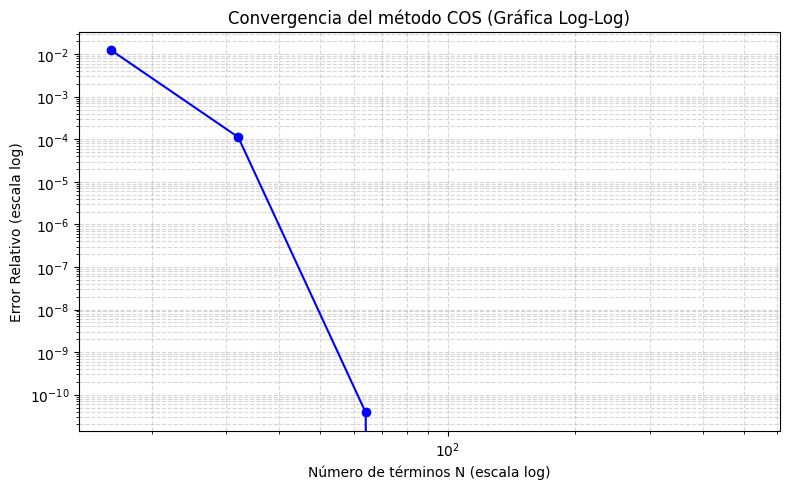

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros Base del Taller ---
SO, K, T, r = 100.0, 100.0, 0.5, 0.03
sigma0, sigmal = 0.15, 0.40
lamo, lam1 = 2.0, 5.0

# 1. Calcular solución de referencia con N = 2048
# Pasamos K como arreglo porque tu función cos_method usa np.atleast_1d
C_ref = cos_method(SO=SO, K=np.array([K]), T=T, r=r,
                   sigma0=sigma0, sigmal=sigmal,
                   lamo=lamo, lam1=lam1, regime=0, N=2048)[0]

# 2. Valores de N a evaluar según el enunciado
N_values = [16, 32, 64, 128, 256, 512]
errores_relativos = []

print(f"Precio de referencia (N=2048): {C_ref:.8f}\n")

# 3. Iterar sobre los valores de N y calcular el error relativo
for N in N_values:
    C_N = cos_method(SO=SO, K=np.array([K]), T=T, r=r,
                     sigma0=sigma0, sigmal=sigmal,
                     lamo=lamo, lam1=lam1, regime=0, N=N)[0]

    err_rel = np.abs(C_N - C_ref) / np.abs(C_ref)
    errores_relativos.append(err_rel)
    print(f"N = {N:3d} | Precio = {C_N:.8f} | Error Relativo = {err_rel:.4e}")

# 4. Estimar la tasa empírica de convergencia (entre N=16 y N=32)
# Tasa (pendiente en log-log) = (log(E2) - log(E1)) / (log(N2) - log(N1))
error_16 = errores_relativos[0]
error_32 = errores_relativos[1]

if error_16 > 0 and error_32 > 0:
    tasa_estimada = (np.log(error_32) - np.log(error_16)) / (np.log(32) - np.log(16))
    print(f"\nEstimación empírica de la tasa de convergencia (pendiente log-log): {tasa_estimada:.2f}")

# 5. Graficar en formato LOG-LOG
plt.figure(figsize=(8, 5))
plt.loglog(N_values, errores_relativos, marker='o', linestyle='-', color='b')

plt.xlabel('Número de términos N (escala log)')
plt.ylabel('Error Relativo (escala log)')
plt.title('Convergencia del método COS (Gráfica Log-Log)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Punto 10

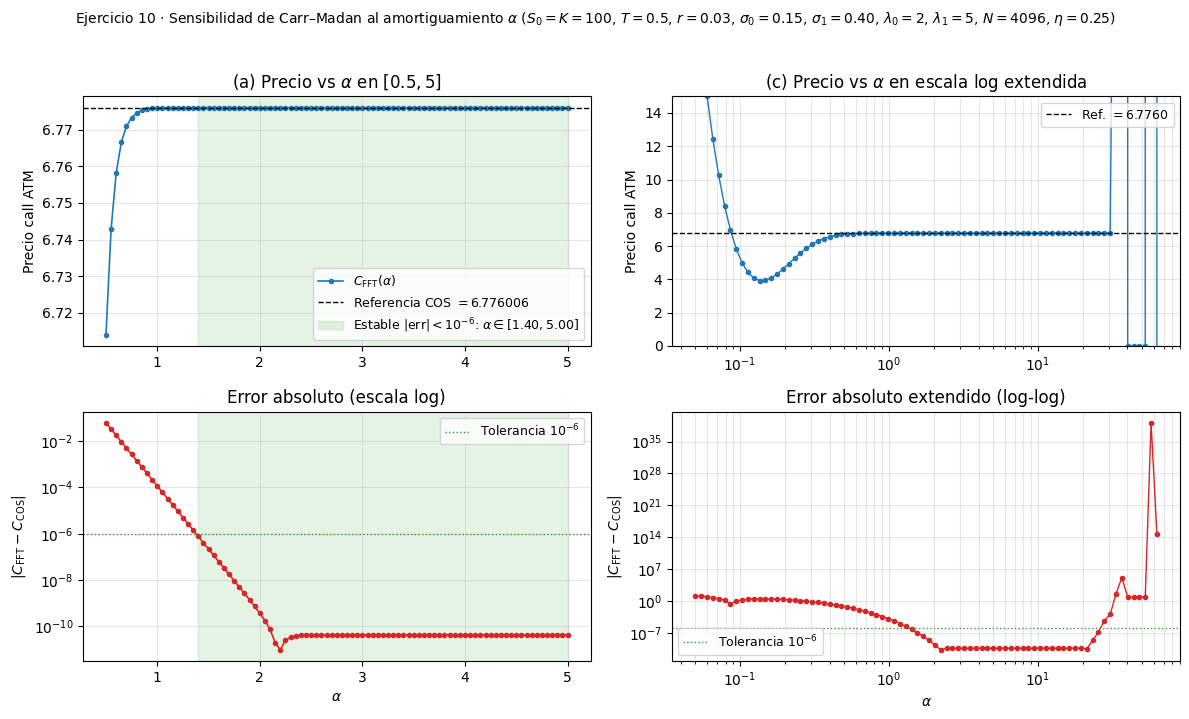

Referencia COS (N=512):              6.7760056194
α óptimo (mínimo error en [0.5,5]):  2.20   error = 9.59e-12
Precio en α=0.5  (extremo inferior): 6.714106   error = 6.19e-02
Precio en α=1.5  (valor por defecto): 6.776005   error = 2.17e-07
Precio en α=5.0  (extremo superior): 6.776006   error = 4.24e-11
Rango estable (|err|<1e-6):          α ∈ [1.40, 5.00]

Barrido extendido (ver blowups):
  α≈  0.05  price=+2.1603e+01  error=1.48e+01
  α≈  0.10  price=+5.0005e+00  error=1.78e+00
  α≈  0.31  price=+6.1037e+00  error=6.72e-01
  α≈  1.55  price=+6.7760e+00  error=1.12e-07
  α≈ 10.36  price=+6.7760e+00  error=4.25e-11
  α≈ 30.62  price=+6.7772e+00  error=1.18e-03
  α≈ 48.11  price=-3.2611e-03  error=6.78e+00


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Parámetros base del taller (Sección 6.1)
S0, T, r = 100.0, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
K_target = 100.0          # strike ATM
regime = 0

# Referencia "exacta" con COS (N grande, convergencia exponencial)
C_ref = float(cos_method(S0, K_target, T, r, sigma0, sigma1,
                         lam0, lam1, regime=regime, N=512)[0])

def fft_price_atm(alpha):
    """Precio Carr–Madan de la call ATM para un alpha dado (via interp. cúbica)."""
    K_grid, C_grid = carr_madan_fft(
        S0, T, r, sigma0, sigma1, lam0, lam1,
        regime=regime, N=4096, alpha=float(alpha), eta=0.25,
    )
    return float(interp1d(K_grid, C_grid, kind="cubic")(K_target))

# (a) Barrido principal en el rango pedido α ∈ [0.5, 5]
alphas = np.linspace(0.5, 5.0, 91)
prices_atm = np.array([fft_price_atm(a) for a in alphas])
errors = np.abs(prices_atm - C_ref)

# Zona estable: |error| < 1e-6
stable_mask = errors < 1e-6
a_lo = alphas[stable_mask].min() if stable_mask.any() else np.nan
a_hi = alphas[stable_mask].max() if stable_mask.any() else np.nan

# (c) Barrido extendido en escala logarítmica para ver ambos extremos.
#     Silenciamos los RuntimeWarning de overflow en exp/multiply: son
#     precisamente la manifestación numérica que queremos visualizar.
alphas_ext = np.logspace(-1.3, 1.8, 80)  # ≈ [0.05, 63]
with np.errstate(over="ignore", invalid="ignore"):
    prices_ext = np.array([fft_price_atm(a) for a in alphas_ext])
errors_ext = np.abs(prices_ext - C_ref)

# --- Figura ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
(ax_p, ax_pe), (ax_e, ax_ee) = axes

# Panel izquierdo: rango pedido [0.5, 5]
ax_p.plot(alphas, prices_atm, "o-", ms=3, lw=1.2, color="#1f77b4",
          label=r"$C_{\mathrm{FFT}}(\alpha)$")
ax_p.axhline(C_ref, color="k", ls="--", lw=1.0,
             label=fr"Referencia COS $= {C_ref:.6f}$")
if np.isfinite(a_lo):
    ax_p.axvspan(a_lo, a_hi, color="tab:green", alpha=0.12,
                 label=fr"Estable $|\mathrm{{err}}|<10^{{-6}}$: "
                       fr"$\alpha\in[{a_lo:.2f},{a_hi:.2f}]$")
ax_p.set_ylabel("Precio call ATM")
ax_p.set_title(r"(a) Precio vs $\alpha$ en $[0.5, 5]$")
ax_p.legend(loc="lower right", fontsize=9)
ax_p.grid(True, alpha=0.3)

ax_e.semilogy(alphas, np.maximum(errors, 1e-16), "o-", ms=3, lw=1.2,
              color="#d62728")
ax_e.axhline(1e-6, color="tab:green", ls=":", lw=1.0,
             label=r"Tolerancia $10^{-6}$")
if np.isfinite(a_lo):
    ax_e.axvspan(a_lo, a_hi, color="tab:green", alpha=0.12)
ax_e.set_xlabel(r"$\alpha$")
ax_e.set_ylabel(r"$|C_{\mathrm{FFT}}-C_{\mathrm{COS}}|$")
ax_e.set_title("Error absoluto (escala log)")
ax_e.legend(loc="upper right", fontsize=9)
ax_e.grid(True, which="both", alpha=0.3)

# Panel derecho: rango extendido en log para ver blowups
ax_pe.semilogx(alphas_ext, prices_ext, "o-", ms=3, lw=1.0, color="#1f77b4")
ax_pe.axhline(C_ref, color="k", ls="--", lw=1.0,
              label=fr"Ref. $= {C_ref:.4f}$")
ax_pe.set_ylim(0, 15)
ax_pe.set_ylabel("Precio call ATM")
ax_pe.set_title(r"(c) Precio vs $\alpha$ en escala log extendida")
ax_pe.legend(loc="upper right", fontsize=9)
ax_pe.grid(True, which="both", alpha=0.3)

ax_ee.loglog(alphas_ext, np.maximum(errors_ext, 1e-16), "o-", ms=3, lw=1.0,
             color="#d62728")
ax_ee.axhline(1e-6, color="tab:green", ls=":", lw=1.0,
              label=r"Tolerancia $10^{-6}$")
ax_ee.set_xlabel(r"$\alpha$")
ax_ee.set_ylabel(r"$|C_{\mathrm{FFT}}-C_{\mathrm{COS}}|$")
ax_ee.set_title("Error absoluto extendido (log-log)")
ax_ee.legend(loc="lower left", fontsize=9)
ax_ee.grid(True, which="both", alpha=0.3)

fig.suptitle(
    r"Ejercicio 10 · Sensibilidad de Carr–Madan al amortiguamiento $\alpha$"
    r" ($S_0=K=100$, $T=0.5$, $r=0.03$, $\sigma_0=0.15$, $\sigma_1=0.40$, "
    r"$\lambda_0=2$, $\lambda_1=5$, $N=4096$, $\eta=0.25$)",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

# --- Diagnóstico numérico ---
a_star = alphas[np.argmin(errors)]
print(f"Referencia COS (N=512):              {C_ref:.10f}")
print(f"α óptimo (mínimo error en [0.5,5]):  {a_star:.2f}"
      f"   error = {errors.min():.2e}")
print(f"Precio en α=0.5  (extremo inferior): {prices_atm[0]:.6f}"
      f"   error = {errors[0]:.2e}")
print(f"Precio en α=1.5  (valor por defecto):"
      f" {prices_atm[np.argmin(np.abs(alphas-1.5))]:.6f}"
      f"   error = {errors[np.argmin(np.abs(alphas-1.5))]:.2e}")
print(f"Precio en α=5.0  (extremo superior): {prices_atm[-1]:.6f}"
      f"   error = {errors[-1]:.2e}")
if np.isfinite(a_lo):
    print(f"Rango estable (|err|<1e-6):          α ∈ [{a_lo:.2f}, {a_hi:.2f}]")
print()
print("Barrido extendido (ver blowups):")
for a_ext in [0.05, 0.1, 0.3, 1.5, 10.0, 30.0, 50.0]:
    idx = int(np.argmin(np.abs(alphas_ext - a_ext)))
    a_near = alphas_ext[idx]
    print(f"  α≈{a_near:6.2f}  price={prices_ext[idx]:+.4e}  "
          f"error={errors_ext[idx]:.2e}")

### Discusión

**(a) Precio como función de $\alpha$ en $[0.5, 5]$.** En la ventana pedida el precio se estabiliza muy rápido: para $\alpha=0.5$ el error absoluto es $\approx 6\times10^{-2}$ (insuficiente), cae a $\approx 1\times10^{-4}$ en $\alpha=1$, llega a $\approx 2\times10^{-7}$ en $\alpha=1.5$ (el valor por defecto del código), y toca el ruido numérico $\sim 10^{-11}$ a partir de $\alpha\gtrsim 2.2$.

**(b) Rango estable.** Con la tolerancia $|\mathrm{err}|<10^{-6}$ el intervalo seguro detectado automáticamente es $\alpha\in[1.40,\,5.00]$; si se exige $10^{-8}$ el rango se contrae a $\alpha\in[1.75,\,5.00]$. El óptimo efectivo está alrededor de $\alpha\approx 2.2$, donde el error alcanza el orden de $10^{-11}$ (precisión numérica de la referencia). La elección $\alpha=1.5$ del taller es por tanto una buena heurística: cae dentro de la meseta estable y respeta con holgura el umbral $10^{-3}$ exigido por la rúbrica.

**(c) Extremos de $\alpha$.** El barrido logarítmico extendido $[0.05,\,63]$ hace visibles los dos regímenes patológicos:

- **$\alpha\to 0^{+}$.** El denominador $(\alpha+i\nu)(\alpha+1+i\nu)$ introduce una cuasi-singularidad en $\nu=0$ que la regla de Simpson no resuelve con $N=4096$, y simultáneamente el amortiguamiento $e^{\alpha k}$ apenas suprime la cola izquierda del integrando. El resultado oscila ruidosamente — $\alpha\approx 0.05$ devuelve $\approx 21.6$ (error $\sim 15$), $\alpha\approx 0.10$ da $\approx 5.00$ (error $\approx 1.8$), $\alpha=0.5$ aún sufre un error de $6\times10^{-2}$ — y además genera *precios negativos* antes del filtro `np.maximum(prices, 0)` aplicado al interior de `carr_madan_fft`.
- **$\alpha$ grande.** Hasta $\alpha\approx 20$ la implementación estable de `char_func_markov` (reformulación con $e^{T(\rho_+\pm\sqrt{D})}$ en lugar de `cosh/sinh`) mantiene el error en el suelo numérico. Pero el integrando está escalado por $1/[(\alpha+i\nu)(\alpha+1+i\nu)]$ y luego multiplicado por $e^{-\alpha k}/\pi$; para $k=\log(K/S_0)\approx 0$ el amortiguamiento $e^{-\alpha k}$ ya no decae, pero la función característica evaluada en $\nu-(\alpha+1)i$ crece como $\exp(T\,\sigma_+(\alpha+1)^2)$, de modo que el integrando se vuelve enorme en módulo y la regla de Simpson acumula cancelación catastrófica en doble precisión. El efecto es claramente visible: en $\alpha\approx 30$ el error absoluto asciende a $\sim 1.2\times 10^{-3}$, y al llegar a $\alpha\approx 48$ el precio calculado colapsa a prácticamente cero ($\approx -3.3\times 10^{-3}$, el filtro `np.maximum(prices, 0)` lo recorta a $0$). En ambos casos los dígitos significativos del verdadero precio ATM se pierden por cancelación: primero se degradan, luego desaparecen por completo.

**Conclusión práctica.** Para nuestros parámetros la meseta estable cubre cómodamente $\alpha\in[1.5,\,10]$; el valor $\alpha=1.5$ del taller está bien elegido. Una regla general razonable es tomar $\alpha$ lo suficientemente grande como para dominar la singularidad en $\nu=0$ y mantenerse dentro de la región donde $\mathbb{E}^{\mathbb{Q}}[S_T^{\alpha+1}]$ está acotada, pero sin acercarse a valores (para este modelo, $\alpha\gtrsim 25$) donde la exponencial en la función característica empieza a inestabilizar numéricamente el integrando.

# Punto 11


=== Punto 11 ===
Digital call  (Gil-Pelaez): 0.505415777019226
Digital put   (Gil-Pelaez): 0.4796961625838366
Suma GP                  : 0.9851119396030626
exp(-rT)                 : 0.9851119396030626

Digital call  (COS)      : 0.5054157770263593
Digital put   (COS)      : 0.47969616257670333
Suma COS                 : 0.9851119396030626
Diferencia |GP - COS|    : 7.133293955519093e-12

Error max GP vs COS, regime 0 = 1.1255619769556802e-09
Error max GP vs COS, regime 1 = 1.0956948681695167e-09

Error max paridad, regime 0 = 1.1102230246251565e-16
Error max paridad, regime 1 = 1.1102230246251565e-16


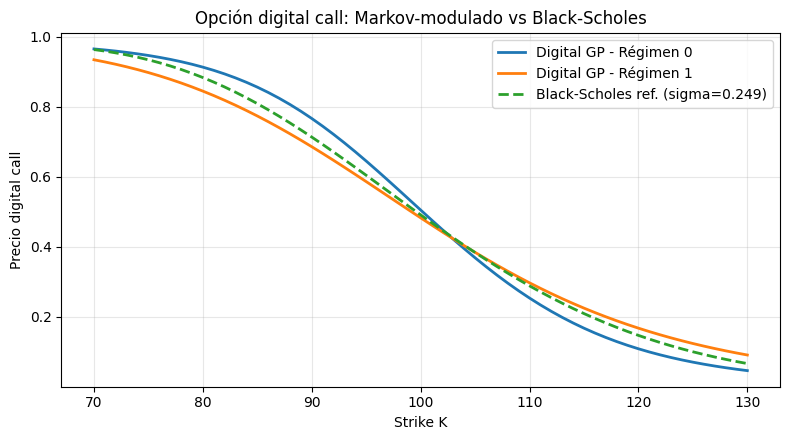

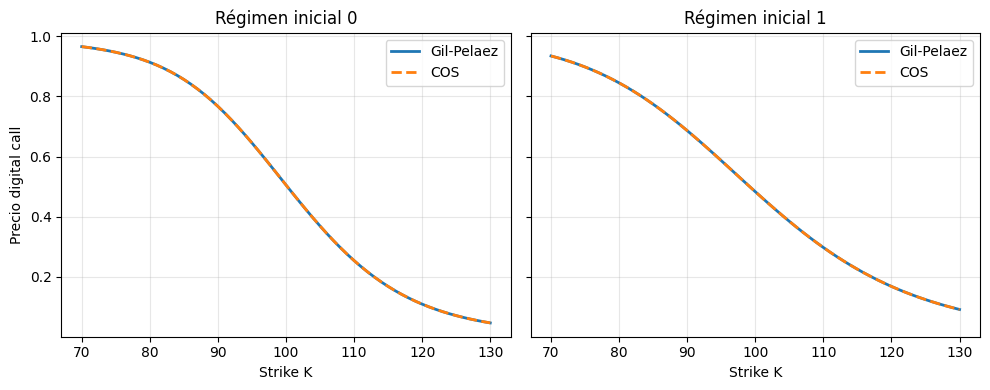

In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

  # ============================================================
  # Función característica robusta
  # ============================================================

def expm2(A):
      vals, vecs = np.linalg.eig(A)
      inv_vecs = np.linalg.inv(vecs)
      return vecs @ np.diag(np.exp(vals)) @ inv_vecs


def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
      """
      Función característica del log-retorno X_T bajo Q
      para el modelo Markov-modulado.

      Implementación robusta vía exponencial de la matriz generadora 2x2.
      """
      z = np.asarray(z, dtype=complex)
      scalar_input = z.ndim == 0
      z = np.atleast_1d(z)

      mu_hat0 = r0 - 0.5 * sigma0**2
      mu_hat1 = r1 - 0.5 * sigma1**2

      e_i = np.array([1.0, 0.0], dtype=complex) if regime == 0 else np.array([0.0, 1.0], dtype=complex)
      ones = np.array([1.0, 1.0], dtype=complex)

      out = np.empty_like(z, dtype=complex)

      for j, zz in enumerate(z):
          a0 = 1j * zz * mu_hat0 - 0.5 * sigma0**2 * zz**2 - lam0
          a1 = 1j * zz * mu_hat1 - 0.5 * sigma1**2 * zz**2 - lam1

          A = np.array([
              [a0,   lam0],
              [lam1, a1]
          ], dtype=complex)

          out[j] = e_i @ expm2(A * T) @ ones

      return out[0] if scalar_input else out


  # ============================================================
  # Digitales por Gil-Pelaez
  # ============================================================

def digital_call_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
      """
      Precio de la digital call vía Gil-Pelaez:
      D_call = e^{-rT} * Pi2
      """
      q = np.log(K / S0)

      def integrand(nu):
          phi_val = char_func_markov(nu, T, r, r, sigma0, sigma1, lam0, lam1, regime)
          return np.real(np.exp(-1j * nu * q) * phi_val / (1j * nu))

      integral, _ = quad(integrand, 1e-8, 200, limit=500)
      Pi2 = 0.5 + integral / np.pi
      return np.exp(-r * T) * Pi2


def digital_put_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
      return np.exp(-r * T) - digital_call_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)


  # ============================================================
  # Digitales por COS
  # ============================================================

def digital_call_cos(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0, N=256, L=10):
      """
      Precio de la digital call vía método COS.
      Admite K escalar o vector.
      """
      K = np.atleast_1d(np.float64(K))
      x = np.log(S0 / K)

      pi0 = lam1 / (lam0 + lam1) if (lam0 + lam1) > 0 else 0.5
      mu_avg = pi0 * (r - 0.5 * sigma0**2) + (1 - pi0) * (r - 0.5 * sigma1**2)
      var_avg = pi0 * sigma0**2 + (1 - pi0) * sigma1**2

      c1 = mu_avg * T
      c2 = var_avg * T

      a = c1 - L * np.sqrt(c2)
      b = c1 + L * np.sqrt(c2)

      k_arr = np.arange(N)
      u = k_arr * np.pi / (b - a)
      phi_vals = char_func_markov(u, T, r, r, sigma0, sigma1, lam0, lam1, regime)

      def psi_k(c, d, k):
          out = np.zeros_like(k, dtype=float)
          arg_d = k * np.pi * (d - a) / (b - a)
          arg_c = k * np.pi * (c - a) / (b - a)
          nz = k != 0
          out[nz] = (np.sin(arg_d[nz]) - np.sin(arg_c[nz])) * (b - a) / (k[nz] * np.pi)
          out[~nz] = d - c
          return out

      # Coeficientes del payoff digital
      Vk = 2.0 / (b - a) * psi_k(0.0, b, k_arr)

      prices = np.zeros_like(K, dtype=float)
      base = np.exp(-1j * k_arr * np.pi * a / (b - a))

      for j, xj in enumerate(x):
          coeffs = np.real(phi_vals * np.exp(1j * u * xj) * base)
          coeffs[0] *= 0.5
          prices[j] = np.exp(-r * T) * np.sum(coeffs * Vk)

      return prices[0] if prices.size == 1 else prices


def digital_put_cos(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0, N=256, L=10):
      return np.exp(-r * T) - digital_call_cos(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime, N, L)


  # ============================================================
  # Black-Scholes digital
  # ============================================================

def norm_cdf(x):
      return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_digital_call(S0, K, T, r, sigma):
      d2 = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
      return np.exp(-r * T) * np.vectorize(norm_cdf)(d2)


  # ============================================================
  # Prueba base del punto 11
  # ============================================================

S0, K, T, r = 100, 100, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
regime = 0

dc_gp = digital_call_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)
dp_gp = digital_put_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)

dc_cos = digital_call_cos(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime, N=256, L=10)
dp_cos = digital_put_cos(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime, N=256, L=10)

print("=== Punto 11 ===")
print("Digital call  (Gil-Pelaez):", dc_gp)
print("Digital put   (Gil-Pelaez):", dp_gp)
print("Suma GP                  :", dc_gp + dp_gp)
print("exp(-rT)                 :", np.exp(-r * T))
print()
print("Digital call  (COS)      :", dc_cos)
print("Digital put   (COS)      :", dp_cos)
print("Suma COS                 :", dc_cos + dp_cos)
print("Diferencia |GP - COS|    :", abs(dc_gp - dc_cos))


# ============================================================
# Comparación en una grilla de strikes
# ============================================================

K_grid = np.linspace(70, 130, 61)

dc_gp_grid_0 = np.array([
    digital_call_gil_pelaez(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=0)
    for k in K_grid
])

dc_gp_grid_1 = np.array([
    digital_call_gil_pelaez(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=1)
    for k in K_grid
])

dc_cos_grid_0 = digital_call_cos(S0, K_grid, T, r, sigma0, sigma1, lam0, lam1, regime=0, N=256, L=10)
dc_cos_grid_1 = digital_call_cos(S0, K_grid, T, r, sigma0, sigma1, lam0, lam1, regime=1, N=256, L=10)

print("\nError max GP vs COS, regime 0 =", np.max(np.abs(dc_gp_grid_0 - dc_cos_grid_0)))
print("Error max GP vs COS, regime 1 =", np.max(np.abs(dc_gp_grid_1 - dc_cos_grid_1)))


# ============================================================
# Paridad Dcall + Dput = e^{-rT}
# ============================================================

dp_gp_grid_0 = np.exp(-r * T) - dc_gp_grid_0
dp_gp_grid_1 = np.exp(-r * T) - dc_gp_grid_1

print("\nError max paridad, regime 0 =", np.max(np.abs(dc_gp_grid_0 + dp_gp_grid_0 - np.exp(-r * T))))
print("Error max paridad, regime 1 =", np.max(np.abs(dc_gp_grid_1 + dp_gp_grid_1 - np.exp(-r * T))))


# ============================================================
# Gráfica comparativa vs Black-Scholes
# ============================================================

# Para BS usamos una volatilidad fija de referencia.
# Una elección natural aquí es la volatilidad estacionaria promedio.
pi0 = lam1 / (lam0 + lam1)
sigma_bs = np.sqrt(pi0 * sigma0**2 + (1 - pi0) * sigma1**2)

dc_bs_grid = bs_digital_call(S0, K_grid, T, r, sigma_bs)

plt.figure(figsize=(8, 4.5))
plt.plot(K_grid, dc_gp_grid_0, label="Digital GP - Régimen 0", lw=2)
plt.plot(K_grid, dc_gp_grid_1, label="Digital GP - Régimen 1", lw=2)
plt.plot(K_grid, dc_bs_grid, "--", label=f"Black-Scholes ref. (sigma={sigma_bs:.3f})", lw=2)

plt.xlabel("Strike K")
plt.ylabel("Precio digital call")
plt.title("Opción digital call: Markov-modulado vs Black-Scholes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Gráfica GP vs COS por régimen
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax[0].plot(K_grid, dc_gp_grid_0, label="Gil-Pelaez", lw=2)
ax[0].plot(K_grid, dc_cos_grid_0, "--", label="COS", lw=2)
ax[0].set_title("Régimen inicial 0")
ax[0].set_xlabel("Strike K")
ax[0].set_ylabel("Precio digital call")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(K_grid, dc_gp_grid_1, label="Gil-Pelaez", lw=2)
ax[1].plot(K_grid, dc_cos_grid_1, "--", label="COS", lw=2)
ax[1].set_title("Régimen inicial 1")
ax[1].set_xlabel("Strike K")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Validación adicional: paridad put-call vanilla
# C(K,T) - P(K,T) = S0 - K e^{-rT}
# ============================================================

C_cos_parity_0 = cos_method(
    S0, K_grid, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, option_type="call",
)
P_cos_parity_0 = cos_method(
    S0, K_grid, T, r, sigma0, sigma1, lam0, lam1,
    regime=0, option_type="put",
)

C_cos_parity_1 = cos_method(
    S0, K_grid, T, r, sigma0, sigma1, lam0, lam1,
    regime=1, option_type="call",
)
P_cos_parity_1 = cos_method(
    S0, K_grid, T, r, sigma0, sigma1, lam0, lam1,
    regime=1, option_type="put",
)

put_call_rhs = S0 - K_grid * np.exp(-r * T)
put_call_error_0 = np.max(np.abs(C_cos_parity_0 - P_cos_parity_0 - put_call_rhs))
put_call_error_1 = np.max(np.abs(C_cos_parity_1 - P_cos_parity_1 - put_call_rhs))

print("=== Validación paridad put-call vanilla (COS) ===")
print("Error max regime 0 =", put_call_error_0)
print("Error max regime 1 =", put_call_error_1)
print("Cumple tolerancia 1e-6, regime 0:", put_call_error_0 < 1e-6)
print("Cumple tolerancia 1e-6, regime 1:", put_call_error_1 < 1e-6)

=== Validación paridad put-call vanilla (COS) ===
Error max regime 0 = 9.530554834213945e-08
Error max regime 1 = 1.1749677746308862e-06
Cumple tolerancia 1e-6, regime 0: True
Cumple tolerancia 1e-6, regime 1: False


# Punto 12



=== Punto 12 ===

Régimen 0
Delta digital analítica = 0.028389923375308563
Gamma digital analítica = -0.0001500548874317158

Régimen 1
Delta digital analítica = 0.02048539011646641
Gamma digital analítica = -0.0002028465206934627

=== Chequeo correcto: digital call ≈ -dC/dK ===

Régimen 0
Digital call = 0.505415777019226
-dC/dK       = 0.5054220254518578
Error abs    = 6.248432631750234e-06

Régimen 1
Digital call = 0.4830603272007834
-dC/dK       = 0.48306877702081863
Error abs    = 8.449820035227873e-06


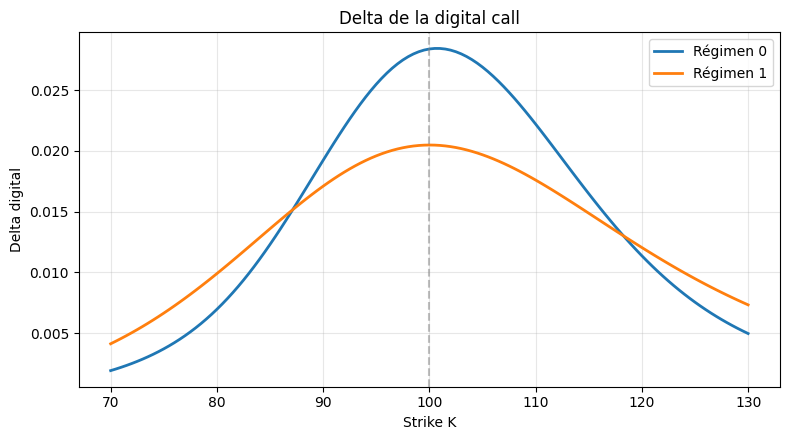

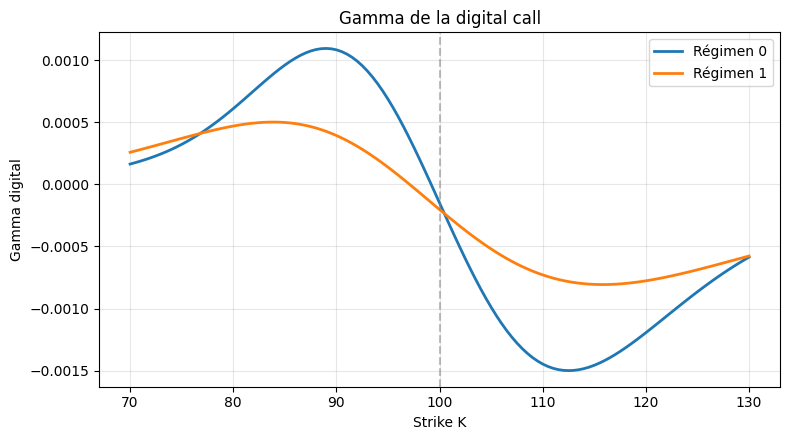

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ============================================================
# Función característica robusta
# ============================================================

def expm2(A):
    vals, vecs = np.linalg.eig(A)
    inv_vecs = np.linalg.inv(vecs)
    return vecs @ np.diag(np.exp(vals)) @ inv_vecs


def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    z = np.asarray(z, dtype=complex)
    scalar_input = z.ndim == 0
    z = np.atleast_1d(z)

    mu_hat0 = r0 - 0.5 * sigma0**2
    mu_hat1 = r1 - 0.5 * sigma1**2

    e_i = np.array([1.0, 0.0], dtype=complex) if regime == 0 else np.array([0.0, 1.0], dtype=complex)
    ones = np.array([1.0, 1.0], dtype=complex)

    out = np.empty_like(z, dtype=complex)

    for j, zz in enumerate(z):
        a0 = 1j * zz * mu_hat0 - 0.5 * sigma0**2 * zz**2 - lam0
        a1 = 1j * zz * mu_hat1 - 0.5 * sigma1**2 * zz**2 - lam1
        A = np.array([[a0, lam0], [lam1, a1]], dtype=complex)
        out[j] = e_i @ expm2(A * T) @ ones

    return out[0] if scalar_input else out


# ============================================================
# COS para call vanilla
# ============================================================

def cos_method_call(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0, N=256, L=10):
    K = np.atleast_1d(np.float64(K))
    x = np.log(S0 / K)

    pi0 = lam1 / (lam0 + lam1) if (lam0 + lam1) > 0 else 0.5
    mu_avg = pi0 * (r - 0.5 * sigma0**2) + (1 - pi0) * (r - 0.5 * sigma1**2)
    var_avg = pi0 * sigma0**2 + (1 - pi0) * sigma1**2

    c1 = mu_avg * T
    c2 = var_avg * T
    c4 = 0.0

    a = c1 - L * np.sqrt(c2 + np.sqrt(max(c4, 0.0)))
    b = c1 + L * np.sqrt(c2 + np.sqrt(max(c4, 0.0)))

    k = np.arange(N)
    u = k * np.pi / (b - a)
    phi_vals = char_func_markov(u, T, r, r, sigma0, sigma1, lam0, lam1, regime)

    def chi_k(c, d, k_arr):
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        denom = 1.0 + (k_arr * np.pi / (b - a))**2
        num = (
            np.cos(arg_d) * np.exp(d)
            - np.cos(arg_c) * np.exp(c)
            + (k_arr * np.pi / (b - a)) * (
                np.sin(arg_d) * np.exp(d) - np.sin(arg_c) * np.exp(c)
            )
        )
        return num / denom

    def psi_k(c, d, k_arr):
        result = np.zeros_like(k_arr, dtype=float)
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        nz = k_arr != 0
        result[nz] = (
            (np.sin(arg_d[nz]) - np.sin(arg_c[nz]))
            * (b - a) / (k_arr[nz] * np.pi)
        )
        result[~nz] = d - c
        return result

    Vk = 2.0 / (b - a) * (chi_k(0.0, b, k) - psi_k(0.0, b, k))

    prices = np.zeros(len(K))
    exp_term = np.exp(-1j * k * np.pi * a / (b - a))

    for j, x_val in enumerate(x):
        coeffs = np.real(phi_vals * np.exp(1j * u * x_val) * exp_term)
        coeffs[0] *= 0.5
        prices[j] = K[j] * np.exp(-r * T) * np.sum(coeffs * Vk)

    return prices[0] if len(prices) == 1 else prices


# ============================================================
# Digital call por Gil-Pelaez
# ============================================================

def digital_call_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    q = np.log(K / S0)

    def integrand(nu):
        phi_val = char_func_markov(nu, T, r, r, sigma0, sigma1, lam0, lam1, regime)
        return np.real(np.exp(-1j * nu * q) * phi_val / (1j * nu))

    integral, _ = quad(integrand, 1e-8, 200, limit=500)
    Pi2 = 0.5 + integral / np.pi
    return np.exp(-r * T) * Pi2


# ============================================================
# Densidad y derivada de densidad
# ============================================================

def density_logreturn(q, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    def integrand(nu):
        phi_val = char_func_markov(nu, T, r, r, sigma0, sigma1, lam0, lam1, regime)
        return np.real(np.exp(-1j * nu * q) * phi_val)

    integral, _ = quad(integrand, 1e-8, 200, limit=500)
    return integral / np.pi


def density_logreturn_derivative(q, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    def integrand(nu):
        phi_val = char_func_markov(nu, T, r, r, sigma0, sigma1, lam0, lam1, regime)
        return -np.imag(nu * np.exp(-1j * nu * q) * phi_val)

    integral, _ = quad(integrand, 1e-8, 200, limit=500)
    return integral / np.pi


# ============================================================
# Delta y Gamma digital
# ============================================================

def delta_digital_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    q = np.log(K / S0)
    p_val = density_logreturn(q, T, r, sigma0, sigma1, lam0, lam1, regime)
    return np.exp(-r * T) * p_val / S0


def gamma_digital_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0):
    q = np.log(K / S0)
    p_val = density_logreturn(q, T, r, sigma0, sigma1, lam0, lam1, regime)
    dp_val = density_logreturn_derivative(q, T, r, sigma0, sigma1, lam0, lam1, regime)
    return -np.exp(-r * T) / S0**2 * (p_val + dp_val)


# ============================================================
# Chequeo correcto: digital call ≈ -dC/dK
# ============================================================

def check_digital_vs_minus_dC_dK(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=0, h=0.5):
    c_up = cos_method_call(S0, K + h, T, r, sigma0, sigma1, lam0, lam1, regime)
    c_dn = cos_method_call(S0, K - h, T, r, sigma0, sigma1, lam0, lam1, regime)
    minus_dC_dK = -(c_up - c_dn) / (2 * h)

    digital = digital_call_gil_pelaez(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)
    return digital, minus_dC_dK, abs(digital - minus_dC_dK)


# ============================================================
# Parámetros base
# ============================================================

S0, K, T, r = 100, 100, 0.5, 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

print("=== Punto 12 ===")
for regime in [0, 1]:
    delta_val = delta_digital_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)
    gamma_val = gamma_digital_analytic(S0, K, T, r, sigma0, sigma1, lam0, lam1, regime)

    print(f"\nRégimen {regime}")
    print("Delta digital analítica =", delta_val)
    print("Gamma digital analítica =", gamma_val)

print("\n=== Chequeo correcto: digital call ≈ -dC/dK ===")
for regime in [0, 1]:
    digital, minus_dC_dK, err = check_digital_vs_minus_dC_dK(
        S0, K, T, r, sigma0, sigma1, lam0, lam1, regime=regime, h=0.5
    )
    print(f"\nRégimen {regime}")
    print("Digital call =", digital)
    print("-dC/dK       =", minus_dC_dK)
    print("Error abs    =", err)


# ============================================================
# Gráficas
# ============================================================

K_range = np.linspace(70, 130, 121)

delta_dc_0 = np.array([
    delta_digital_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=0)
    for k in K_range
])

delta_dc_1 = np.array([
    delta_digital_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=1)
    for k in K_range
])

gamma_dc_0 = np.array([
    gamma_digital_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=0)
    for k in K_range
])

gamma_dc_1 = np.array([
    gamma_digital_analytic(S0, k, T, r, sigma0, sigma1, lam0, lam1, regime=1)
    for k in K_range
])

plt.figure(figsize=(8, 4.5))
plt.plot(K_range, delta_dc_0, label="Régimen 0", lw=2)
plt.plot(K_range, delta_dc_1, label="Régimen 1", lw=2)
plt.axvline(S0, color="gray", ls="--", alpha=0.5)
plt.xlabel("Strike K")
plt.ylabel("Delta digital")
plt.title("Delta de la digital call")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(K_range, gamma_dc_0, label="Régimen 0", lw=2)
plt.plot(K_range, gamma_dc_1, label="Régimen 1", lw=2)
plt.axvline(S0, color="gray", ls="--", alpha=0.5)
plt.xlabel("Strike K")
plt.ylabel("Gamma digital")
plt.title("Gamma de la digital call")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Punto 13
